In [1]:
import os
import time
import math

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device yang digunakan:", device)

Device yang digunakan: cpu


In [2]:
text_path = "dataset_text/data.txt"

with open(text_path, "r", encoding="utf-8") as file:
    text = file.read().lower()

print("Jumlah karakter dalam dataset:", len(text))


Jumlah karakter dalam dataset: 1997757


link url dataset yang digunakan: https://www.kaggle.com/datasets/agustrinaldo/nlp-emotion-text-dataset-bahasa-indonesia

In [3]:
max_chars = 50000
text = text[:max_chars]

print("Jumlah karakter yang digunakan:", len(text))
print("\nContoh isi dataset:")
print(text[:500])

if len(text) == 0:
    raise ValueError("Dataset kosong. Periksa isi file dataset_text/data.txt")

lines = text.splitlines()

print("\nJumlah baris/kalimat:", len(lines))
print("Contoh 5 baris pertama:")

for line in lines[:5]:
    print("-", line)

Jumlah karakter yang digunakan: 50000

Contoh isi dataset:
saya tidak merasa terhina;kesedihan
saya bisa berubah dari merasa sangat putus asa menjadi sangat berharap hanya dari berada di sekitar seseorang yang peduli dan terjaga;kesedihan
saya mengambil waktu sebentar untuk memposting saya merasa serakah salah;kemarahan
saya pernah merasa nostalgia tentang perapian saya akan tahu bahwa itu masih di properti;cinta
saya merasa kesal;kemarahan
saya merasa sedikit terbebani akhir-akhir ini tidak yakin mengapa itu;kesedihan
saya telah mengonsumsi atau miligr

Jumlah baris/kalimat: 389
Contoh 5 baris pertama:
- saya tidak merasa terhina;kesedihan
- saya bisa berubah dari merasa sangat putus asa menjadi sangat berharap hanya dari berada di sekitar seseorang yang peduli dan terjaga;kesedihan
- saya mengambil waktu sebentar untuk memposting saya merasa serakah salah;kemarahan
- saya pernah merasa nostalgia tentang perapian saya akan tahu bahwa itu masih di properti;cinta
- saya merasa kesal;kem

### Tokenization Character-level

In [4]:
chars = sorted(list(set(text)))

char_to_idx = {char: idx for idx, char in enumerate(chars)}
idx_to_char = {idx: char for idx, char in enumerate(chars)}

vocab_size = len(chars)

print("\nJumlah karakter unik:", vocab_size)
print("Daftar karakter unik:")
print(chars)

encoded_text = [char_to_idx[char] for char in text]

print("\nContoh encoded text:")
print(encoded_text[:100])


Jumlah karakter unik: 32
Daftar karakter unik:
['\n', ' ', ',', '-', ';', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '\u200b']

Contoh encoded text:
[23, 5, 29, 5, 1, 24, 13, 8, 5, 15, 1, 17, 9, 22, 5, 23, 5, 1, 24, 9, 22, 12, 13, 18, 5, 4, 15, 9, 23, 9, 8, 13, 12, 5, 18, 0, 23, 5, 29, 5, 1, 6, 13, 23, 5, 1, 6, 9, 22, 25, 6, 5, 12, 1, 8, 5, 22, 13, 1, 17, 9, 22, 5, 23, 5, 1, 23, 5, 18, 11, 5, 24, 1, 20, 25, 24, 25, 23, 1, 5, 23, 5, 1, 17, 9, 18, 14, 5, 8, 13, 1, 23, 5, 18, 11, 5, 24, 1, 6, 9]


### Dataset Sequence

In [5]:
class TextDataset(Dataset):
    def __init__(self, encoded_text, sequence_length):
        self.encoded_text = encoded_text
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.encoded_text) - self.sequence_length

    def __getitem__(self, idx):
        input_seq = self.encoded_text[idx : idx + self.sequence_length]
        target_seq = self.encoded_text[idx + 1 : idx + self.sequence_length + 1]

        input_seq = torch.tensor(input_seq, dtype=torch.long)
        target_seq = torch.tensor(target_seq, dtype=torch.long)

        return input_seq, target_seq


### Data Loader

In [6]:
sequence_length = 50
batch_size = 128

dataset_text = TextDataset(encoded_text, sequence_length)

train_loader_text = DataLoader(
    dataset_text,
    batch_size=batch_size,
    shuffle=True
)

print("\nJumlah sequence training:", len(dataset_text))


Jumlah sequence training: 49950


### menghitung parameter

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### MODEL LSTM TEXT GENERATOR

In [8]:
class LSTMTextGenerator(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=1):
        super(LSTMTextGenerator, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Mengubah index karakter menjadi vector embedding
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim
        )

        # LSTM mempelajari pola urutan karakter
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # Fully connected layer untuk memprediksi karakter berikutnya
        self.fc = nn.Linear(
            in_features=hidden_dim,
            out_features=vocab_size
        )

    def forward(self, x, hidden=None):
        x = self.embedding(x)

        output, hidden = self.lstm(x, hidden)

        output = self.fc(output)

        return output, hidden

### Model Transformer text generator

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embedding_dim, max_length=5000):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_length, embedding_dim)

        position = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, embedding_dim, 2).float()
            * (-math.log(10000.0) / embedding_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        sequence_length = x.size(1)

        x = x + self.pe[:, :sequence_length, :]

        return x
    
class TransformerTextGenerator(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=64,
        num_heads=4,
        hidden_dim=128,
        num_layers=1,
        dropout=0.1,
        max_length=5000
    ):
        super(TransformerTextGenerator, self).__init__()

        self.embedding_dim = embedding_dim

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim
        )

        self.positional_encoding = PositionalEncoding(
            embedding_dim=embedding_dim,
            max_length=max_length
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(
            in_features=embedding_dim,
            out_features=vocab_size
        )

    def generate_square_subsequent_mask(self, size):
        mask = torch.triu(
            torch.ones(size, size),
            diagonal=1
        ).bool()

        return mask.to(device)

    def forward(self, x):
        sequence_length = x.size(1)

        x = self.embedding(x) * math.sqrt(self.embedding_dim)

        x = self.positional_encoding(x)

        mask = self.generate_square_subsequent_mask(sequence_length)

        output = self.transformer(x, mask=mask)

        output = self.fc(output)

        return output

In [10]:
embedding_dim = 64
hidden_dim = 128
num_layers = 1
num_heads = 4

model_lstm = LSTMTextGenerator(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers
).to(device)

model_transformer = TransformerTextGenerator(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_heads=num_heads,
    hidden_dim=hidden_dim,
    num_layers=num_layers
).to(device)

print("\nModel LSTM:")
print(model_lstm)
print("Jumlah parameter LSTM:", count_parameters(model_lstm))

print("\nModel Transformer:")
print(model_transformer)
print("Jumlah parameter Transformer:", count_parameters(model_transformer))


Model LSTM:
LSTMTextGenerator(
  (embedding): Embedding(32, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=32, bias=True)
)
Jumlah parameter LSTM: 105504

Model Transformer:
TransformerTextGenerator(
  (embedding): Embedding(32, 64)
  (positional_encoding): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=Fals

### Loss Function dan Optimizer

In [11]:
criterion_lstm = nn.CrossEntropyLoss()
criterion_transformer = nn.CrossEntropyLoss()

optimizer_lstm = optim.Adam(
    model_lstm.parameters(),
    lr=0.001
)

optimizer_transformer = optim.Adam(
    model_transformer.parameters(),
    lr=0.001
)

### Training Model

In [12]:
num_epochs_lstm = 5

train_losses_lstm = []

start = time.time()

for epoch in range(num_epochs_lstm):
    model_lstm.train()

    total_loss = 0

    for input_seq, target_seq in train_loader_text:
        input_seq = input_seq.to(device)
        target_seq = target_seq.to(device)

        optimizer_lstm.zero_grad()

        output, hidden = model_lstm(input_seq)

        # output shape     : [batch_size, sequence_length, vocab_size]
        # target_seq shape : [batch_size, sequence_length]
        # CrossEntropyLoss membutuhkan:
        # output     : [batch_size * sequence_length, vocab_size]
        # target_seq : [batch_size * sequence_length]

        output = output.reshape(-1, vocab_size)
        target_seq = target_seq.reshape(-1)

        loss = criterion_lstm(output, target_seq)

        loss.backward()

        optimizer_lstm.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_text)
    train_losses_lstm.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs_lstm}], LSTM Loss: {avg_loss:.4f}")

end = time.time()

training_time_lstm = end - start

print("Training time LSTM:", training_time_lstm, "seconds")

Epoch [1/5], LSTM Loss: 1.7124
Epoch [2/5], LSTM Loss: 1.1793
Epoch [3/5], LSTM Loss: 1.0280
Epoch [4/5], LSTM Loss: 0.9274
Epoch [5/5], LSTM Loss: 0.8470
Training time LSTM: 78.05823302268982 seconds


In [13]:
num_epochs_transformer = 5

train_losses_transformer = []

start = time.time()

for epoch in range(num_epochs_transformer):
    model_transformer.train()

    total_loss = 0

    for input_seq, target_seq in train_loader_text:
        input_seq = input_seq.to(device)
        target_seq = target_seq.to(device)

        optimizer_transformer.zero_grad()

        output = model_transformer(input_seq)

        # output shape     : [batch_size, sequence_length, vocab_size]
        # target_seq shape : [batch_size, sequence_length]

        output = output.reshape(-1, vocab_size)
        target_seq = target_seq.reshape(-1)

        loss = criterion_transformer(output, target_seq)

        loss.backward()

        optimizer_transformer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_text)
    train_losses_transformer.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs_transformer}], Transformer Loss: {avg_loss:.4f}")

end = time.time()

training_time_transformer = end - start

print("Training time Transformer:", training_time_transformer, "seconds")

Epoch [1/5], Transformer Loss: 2.0926
Epoch [2/5], Transformer Loss: 1.9728
Epoch [3/5], Transformer Loss: 1.9531
Epoch [4/5], Transformer Loss: 1.9338
Epoch [5/5], Transformer Loss: 1.9193
Training time Transformer: 70.61433100700378 seconds


### Grafik Training Loss

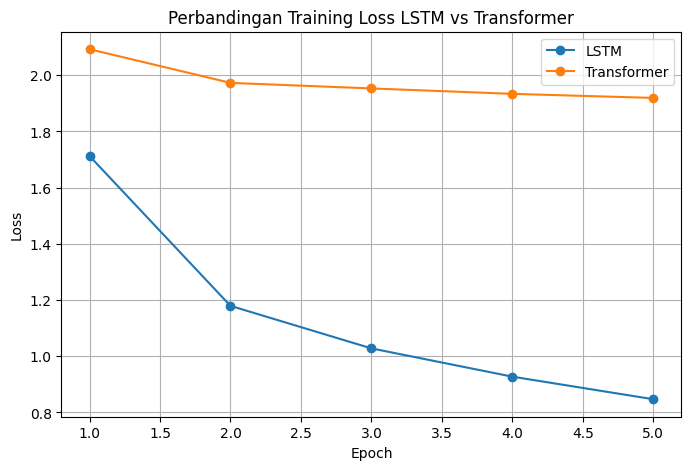

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses_lstm) + 1),
    train_losses_lstm,
    marker="o",
    label="LSTM"
)

plt.plot(
    range(1, len(train_losses_transformer) + 1),
    train_losses_transformer,
    marker="o",
    label="Transformer"
)

plt.title("Perbandingan Training Loss LSTM vs Transformer")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
def generate_text_lstm(model, prompt, length=300, temperature=0.8):
    model.eval()

    generated_text = prompt.lower()

    input_indices = [
        char_to_idx[char]
        for char in generated_text
        if char in char_to_idx
    ]

    if len(input_indices) == 0:
        return "Prompt tidak memiliki karakter yang ada di vocabulary dataset."

    input_tensor = torch.tensor(
        input_indices,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    hidden = None

    with torch.no_grad():
        for _ in range(length):
            output, hidden = model(input_tensor, hidden)

            last_output = output[:, -1, :]

            last_output = last_output / temperature

            probabilities = torch.softmax(last_output, dim=-1)

            next_char_idx = torch.multinomial(
                probabilities,
                num_samples=1
            ).item()

            next_char = idx_to_char[next_char_idx]

            generated_text += next_char

            input_tensor = torch.tensor(
                [[next_char_idx]],
                dtype=torch.long
            ).to(device)

    return generated_text



### Generate Text dari Prompt

In [19]:
def generate_text_transformer(model, prompt, length=300, temperature=0.8):
    model.eval()

    generated_text = prompt.lower()

    input_indices = [
        char_to_idx[char]
        for char in generated_text
        if char in char_to_idx
    ]

    if len(input_indices) == 0:
        return "Prompt tidak memiliki karakter yang ada di vocabulary dataset."

    with torch.no_grad():
        for _ in range(length):
            input_tensor = torch.tensor(
                input_indices,
                dtype=torch.long
            ).unsqueeze(0).to(device)

            output = model(input_tensor)

            last_output = output[:, -1, :]

            last_output = last_output / temperature

            probabilities = torch.softmax(last_output, dim=-1)

            next_char_idx = torch.multinomial(
                probabilities,
                num_samples=1
            ).item()

            next_char = idx_to_char[next_char_idx]

            generated_text += next_char

            input_indices.append(next_char_idx)

            # Batasi panjang konteks agar proses generate tidak terlalu berat
            if len(input_indices) > sequence_length:
                input_indices = input_indices[-sequence_length:]

    return generated_text

### contoh prompt dari hasil generasi

In [21]:
prompt = "saya merasa"

generated_lstm = generate_text_lstm(
    model=model_lstm,
    prompt=prompt,
    length=300,
    temperature=0.8
)

generated_transformer = generate_text_transformer(
    model=model_transformer,
    prompt=prompt,
    length=300,
    temperature=0.8
)

print("=" * 80)
print("Prompt:")
print(prompt)

print("\nHasil Generate LSTM:")
print(generated_lstm)

print("\nHasil Generate Transformer:")
print(generated_transformer)

Prompt:
saya merasa

Hasil Generate LSTM:
saya merasa panya ketika saya bisa mengedikan lebih mengatakan bagi saya melakukan apa yang tersisung dan bahkan saya yang bermusukan saya bisa mengatakan apa yang saya tidak melakukan kota sedang meninggal kala-baik saya berdalamanasi seperti saya tidak bersenan dan saya harus terhambat setiap ama seksua keng

Hasil Generate Transformer:
saya merasa kara san sa singakiayan yan da ben tu mbeta san yayaya sturcamera satapadu kamerorang mbeprasa da sa ma di sayanya bengaa jukangahituramemba da ja saya ta saya seriayakayahang saya membenikandanyayan iran sa layaya ben yah mu jan h ti mali-haur da merinti didantang aiangupi rt yang saya bakayang pu


### contoh output

In [22]:
prompts = [
    "saya merasa",
    "hari ini",
    "aku ingin",
    "perasaan saya",
    "ketika melihat"
]

for prompt in prompts:
    generated_lstm = generate_text_lstm(
        model=model_lstm,
        prompt=prompt,
        length=200,
        temperature=0.8
    )

    generated_transformer = generate_text_transformer(
        model=model_transformer,
        prompt=prompt,
        length=200,
        temperature=0.8
    )

    print("=" * 80)
    print("Prompt:", prompt)

    print("\nGenerated Text LSTM:")
    print(generated_lstm)

    print("\nGenerated Text Transformer:")
    print(generated_transformer)


Prompt: saya merasa

Generated Text LSTM:
saya merasa tidak ada yang tidak tahu pakai karena saya akan seanda diteritahu berada di depan dan sekarang anak anda juga bahwa beberapa hal-hari itu saya membesahnya tidak akan pergi ke dalam dipercaya di man 

Generated Text Transformer:
saya merasasa sa dian panta banti ikamang dangan saka beramemen pari mbembu muk bung;kedi;kemben
sa lu sasatayayaya merat sa sa paya ma mebiaih mbelatucarong pengkali sang sa pi toter dantahn ban mah bi kanitara
Prompt: hari ini

Generated Text LSTM:
hari ini tetapi saya hanya merasa sangat labu;kesedihan
saya cenyekar saya menyumbut bahwa saya agal dicak selalu yang tidak ada dengan lagi dan persis saya seleluatnya dalam hidup saya;kegembiraan
saya berha

Generated Text Transformer:
hari ini mengudangan sayang benga hanyakangan bupan men a sa t san ya ka serela kersan t dan merambindan dan;kediran
sayayayayaya ti membiku mbemeral din i mberorantang pah damberadan mbukin mbeleran dikaan m
Prompt: aku ingin



### Komparasi temperature

In [23]:
prompt = "saya merasa"

temperatures = [0.5, 0.8, 1.2]

for temp in temperatures:
    generated_lstm = generate_text_lstm(
        model=model_lstm,
        prompt=prompt,
        length=250,
        temperature=temp
    )

    generated_transformer = generate_text_transformer(
        model=model_transformer,
        prompt=prompt,
        length=250,
        temperature=temp
    )

    print("=" * 80)
    print(f"Temperature: {temp}")

    print("\nLSTM:")
    print(generated_lstm)

    print("\nTransformer:")
    print(generated_transformer)


Temperature: 0.5

LSTM:
saya merasa panas dan saya merasa seperti saya sakit di selama berhasil tentang pergi dan atas kelas pada anta perti sekarang saya merasa seperti saya kerena dan itu adalah pengaal dan saya merasa seseorang terjadi dalam keluar dan saya merasa bahwa mereka dia 

Transformer:
saya merasa hikan men tan masaikayang sa dira sangayan sa sayanya mereraha ya pera tiang k san sa da ih memban saya kaya din dan sanya tayaya sayang sa daya aya dalaha bera ka mban panyang t di danyanyan bangan din saya seraya mba sa yakanga yanyan meran hang y
Temperature: 0.8

LSTM:
saya merasa berani kebutuhan bahwa saya mengebulan seperti mendapatkan perharapi;kesedihan
saya merasa bagaimana saya tidak ingin mencari ke sama tidak begitu ingin pelenaran pengangah bagaimana saya selamangkat kedua tulam yakti oleh saya dan saya merasa tanda

Transformer:
saya merasa sakatatida ma tahalamebatiku mben danasuka isalutelayayatulupemu bat tik yananyalakun dangankengg daranyahaten ingalbalan mbu 

In [24]:
print("\nTabel Perbandingan LSTM vs Transformer")
print("-" * 100)
print(f"{'Model':<20} {'Final Loss':<20} {'Training Time (s)':<20} {'Jumlah Parameter':<20}")
print("-" * 100)

print(
    f"{'LSTM':<20} "
    f"{train_losses_lstm[-1]:<20.4f} "
    f"{training_time_lstm:<20.2f} "
    f"{count_parameters(model_lstm):<20}"
)

print(
    f"{'Transformer':<20} "
    f"{train_losses_transformer[-1]:<20.4f} "
    f"{training_time_transformer:<20.2f} "
    f"{count_parameters(model_transformer):<20}"
)

print("-" * 100)


Tabel Perbandingan LSTM vs Transformer
----------------------------------------------------------------------------------------------------
Model                Final Loss           Training Time (s)    Jumlah Parameter    
----------------------------------------------------------------------------------------------------
LSTM                 0.8470               78.06                105504              
Transformer          1.9193               70.61                37600               
----------------------------------------------------------------------------------------------------



### Eksperimen SEQUENCE LENGTH

In [25]:
def train_lstm_sequence_experiment(sequence_length_exp, num_epochs=3):
    print("=" * 80)
    print(f"Training LSTM dengan sequence_length = {sequence_length_exp}")
    print("=" * 80)

    dataset_exp = TextDataset(encoded_text, sequence_length_exp)

    train_loader_exp = DataLoader(
        dataset_exp,
        batch_size=batch_size,
        shuffle=True
    )

    model_exp = LSTMTextGenerator(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers
    ).to(device)

    criterion_exp = nn.CrossEntropyLoss()

    optimizer_exp = optim.Adam(
        model_exp.parameters(),
        lr=0.001
    )

    losses_exp = []

    start = time.time()

    for epoch in range(num_epochs):
        model_exp.train()

        total_loss = 0

        for input_seq, target_seq in train_loader_exp:
            input_seq = input_seq.to(device)
            target_seq = target_seq.to(device)

            optimizer_exp.zero_grad()

            output, hidden = model_exp(input_seq)

            output = output.reshape(-1, vocab_size)
            target_seq = target_seq.reshape(-1)

            loss = criterion_exp(output, target_seq)

            loss.backward()

            optimizer_exp.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader_exp)
        losses_exp.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    end = time.time()

    training_time_exp = end - start

    print("Training time:", training_time_exp, "seconds")

    return model_exp, losses_exp, training_time_exp


sequence_lengths = [30, 50, 80]

num_epochs_sequence_exp = 3

sequence_results = {}

for seq_len in sequence_lengths:
    model_exp, losses_exp, training_time_exp = train_lstm_sequence_experiment(
        sequence_length_exp=seq_len,
        num_epochs=num_epochs_sequence_exp
    )

    sequence_results[seq_len] = {
        "model": model_exp,
        "losses": losses_exp,
        "training_time": training_time_exp
    }

Training LSTM dengan sequence_length = 30
Epoch [1/3], Loss: 1.7385
Epoch [2/3], Loss: 1.2375
Epoch [3/3], Loss: 1.0991
Training time: 40.57022786140442 seconds
Training LSTM dengan sequence_length = 50
Epoch [1/3], Loss: 1.6992
Epoch [2/3], Loss: 1.1640
Epoch [3/3], Loss: 1.0130
Training time: 59.6503119468689 seconds
Training LSTM dengan sequence_length = 80
Epoch [1/3], Loss: 1.7046
Epoch [2/3], Loss: 1.1456
Epoch [3/3], Loss: 0.9694
Training time: 84.74745106697083 seconds


### GRAFIK LOSS EKSPERIMEN SEQUENCE LENGTH

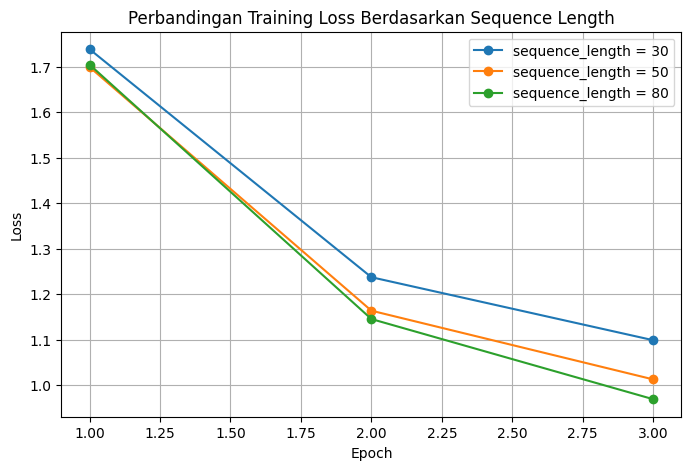

In [26]:
plt.figure(figsize=(8, 5))

for seq_len in sequence_lengths:
    losses = sequence_results[seq_len]["losses"]

    plt.plot(
        range(1, num_epochs_sequence_exp + 1),
        losses,
        marker="o",
        label=f"sequence_length = {seq_len}"
    )

plt.title("Perbandingan Training Loss Berdasarkan Sequence Length")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### OUTPUT GENERATED TEXT BERDASARKAN SEQUENCE LENGTH

In [27]:
prompt = "saya merasa"

for seq_len in sequence_lengths:
    model_exp = sequence_results[seq_len]["model"]

    generated = generate_text_lstm(
        model=model_exp,
        prompt=prompt,
        length=250,
        temperature=0.8
    )

    print("=" * 80)
    print(f"Sequence Length: {seq_len}")
    print(generated)

Sequence Length: 30
saya merasa sagar sangat cakti saya sepantur iina dalam kamenam saya merasa dirimati saya merasa seperti tada sedang tidak merasa sangat memakaimana saya merasa agik saya tidak merasa terlanggu;kemarahan
kusedik saya benar menudih tetapi saya merasa kesal lagan
Sequence Length: 50
saya merasa seperti saya hal dengan perasaan smatu yang sangat saru itu jadan bagi yang saya masih merasa kuntif merasa merlukurnya di sekitar longong karena merasa berusang luar bahwa menjadi bahwa dari melahwah ibu pahit pernah membuat itu saya di poda beleta
Sequence Length: 80
saya merasa pertama penderitanya adalah kaja saya karena saya dan menengah ian pun yang pasu aku pajah yang malih kita di jika anti menulis bukan merasa bahwa berudar bialayan merasa lakukan anak yang bayon dan membeli saya tidak merasa kepada saya mendapatkan 


In [28]:
print("\nTabel Perbandingan Eksperimen Sequence Length")
print("-" * 90)
print(f"{'Sequence Length':<20} {'Final Loss':<20} {'Training Time (s)':<20}")
print("-" * 90)

for seq_len in sequence_lengths:
    final_loss = sequence_results[seq_len]["losses"][-1]
    training_time = sequence_results[seq_len]["training_time"]

    print(f"{seq_len:<20} {final_loss:<20.4f} {training_time:<20.2f}")

print("-" * 90)


Tabel Perbandingan Eksperimen Sequence Length
------------------------------------------------------------------------------------------
Sequence Length      Final Loss           Training Time (s)   
------------------------------------------------------------------------------------------
30                   1.0991               40.57               
50                   1.0130               59.65               
80                   0.9694               84.75               
------------------------------------------------------------------------------------------


## Perbandingan LSTM Text Generator dan Transformer Text Generator

Pada implementasi text generation, dilakukan perbandingan antara **LSTM Text Generator** dan **Transformer Text Generator** menggunakan dataset teks Bahasa Indonesia. Kedua model menggunakan pendekatan **character-level text generation**, yaitu model memprediksi karakter berikutnya berdasarkan urutan karakter sebelumnya.

Secara teori, **Transformer** memiliki kemampuan yang lebih kuat untuk text generation karena menggunakan mekanisme **self-attention**. Dengan self-attention, Transformer dapat melihat hubungan antar token dalam sequence secara lebih luas dibandingkan LSTM. Namun, pada eksperimen ini, hasil Transformer belum lebih baik daripada LSTM. Hal ini menunjukkan bahwa keunggulan Transformer biasanya baru terlihat jika didukung oleh jumlah data yang cukup besar, kapasitas model yang memadai, dan waktu training yang lebih panjang.

### 1. Kualitas Kalimat

Berdasarkan hasil eksperimen, kualitas kalimat yang dihasilkan oleh **LSTM lebih baik dan lebih terbaca** dibandingkan Transformer. Hal ini terlihat dari nilai loss akhir, yaitu **0.8470 pada LSTM** dan **1.9193 pada Transformer**.

Nilai loss LSTM yang lebih kecil menunjukkan bahwa LSTM lebih berhasil mempelajari pola karakter dari dataset. Output LSTM memang masih memiliki banyak kesalahan, typo, dan fragmen kata, tetapi beberapa bagian masih membentuk pola kalimat Bahasa Indonesia sederhana. Misalnya, model masih dapat menghasilkan pola seperti **“saya merasa”**, **“karena”**, atau **“tetapi”**.

Sebaliknya, output Transformer pada setup ini masih terlihat seperti susunan karakter acak yang hanya sesekali membentuk potongan kata. Kalimat yang dihasilkan belum cukup layak sebagai teks alami. Jadi, pada eksperimen ini, LSTM menghasilkan kualitas kalimat yang lebih baik daripada Transformer.

Namun, kesimpulan ini perlu dilihat secara kritis. Bukan berarti Transformer selalu lebih buruk daripada LSTM. Masalah utamanya adalah Transformer pada eksperimen ini masih **under-trained** dan kapasitas modelnya dibuat kecil agar dapat berjalan ringan. Transformer membutuhkan data dan komputasi yang lebih besar agar kemampuannya terlihat optimal.

### 2. Koherensi Teks

Dari sisi koherensi, LSTM menunjukkan **koherensi lokal** yang lebih baik. Artinya, dalam jarak pendek, sekitar satu sampai dua frasa, teks LSTM masih terlihat memiliki hubungan. Akan tetapi, setelah beberapa puluh karakter, teks mulai keluar dari konteks, berulang, atau membentuk kata yang tidak jelas.

Transformer tidak menunjukkan koherensi semantik yang stabil pada eksperimen ini. Banyak output Transformer berupa **pseudo-kata**, yaitu susunan karakter yang mirip kata, tetapi tidak memiliki arti yang jelas. Selain itu, antar potongan teks juga sering tidak memiliki hubungan.

Dengan demikian, LSTM lebih baik daripada Transformer untuk koherensi pada eksperimen ini. Namun, keduanya masih belum mampu menghasilkan paragraf panjang yang benar-benar koheren. Koherensi LSTM juga masih dapat disebut koherensi semu, karena sebagian besar berasal dari pola template yang sering muncul di dataset, misalnya **“saya merasa”**, bukan karena model benar-benar memahami makna kalimat.

### 3. Repetisi Kata

Repetisi muncul cukup jelas pada kedua model. Pada LSTM, repetisi sering muncul dalam bentuk pengulangan frasa seperti **“saya merasa”**. Pada Transformer, repetisi lebih parah karena sering muncul sebagai pengulangan fragmen karakter atau suku kata, misalnya pola yang mirip **“sayaya...”** atau potongan kata yang berulang.

Repetisi ini wajar terjadi pada character-level text generation, terutama jika dataset berisi banyak kalimat dengan pola yang mirip. Karena dataset yang digunakan adalah dataset emosi, kemungkinan banyak kalimat memiliki struktur serupa, misalnya kalimat yang diawali dengan ungkapan perasaan. Akibatnya, model belajar mengulang pola tersebut.

Penggunaan temperature yang lebih tinggi, misalnya **1.2**, memang dapat membuat output lebih bervariasi. Namun, variasi yang terlalu tinggi juga dapat membuat kata menjadi semakin rusak dan tidak bermakna. Jadi, temperature tinggi tidak selalu memperbaiki kualitas teks, tetapi hanya meningkatkan keacakan output.

### 4. Kesalahan Grammar

Dari sisi grammar, LSTM masih lebih baik dibandingkan Transformer. LSTM kadang menghasilkan urutan kata yang terlihat masuk akal, walaupun masih banyak kesalahan sintaks, typo, dan kata tidak standar. Beberapa bagian teks masih menyerupai struktur kalimat Bahasa Indonesia.

Transformer memiliki kesalahan grammar yang lebih ekstrem. Hal ini karena banyak output Transformer bahkan belum berhasil membentuk kata yang valid. Jika unit kata belum terbentuk dengan baik, maka struktur grammar kalimat juga otomatis menjadi buruk.

Salah satu faktor penting yang terlihat dari hasil output adalah adanya token label seperti **`;kesedihan`** atau **`;kemarahan`** yang ikut muncul dalam teks generasi. Hal ini menunjukkan bahwa data yang digunakan masih mengandung label atau tag dari dataset asli. Akibatnya, model tidak hanya belajar pola kalimat alami, tetapi juga belajar pola **“teks + label”**. Ini menjadi salah satu penyebab hasil generasi kurang natural.

### 5. Pengaruh Panjang Prompt

Prompt yang digunakan pada eksperimen masih cukup pendek, misalnya **“saya merasa”**, **“hari ini”**, **“aku ingin”**, dan **“perasaan saya”**. Pada LSTM, prompt pendek masih dapat digunakan untuk menghasilkan lanjutan teks karena model sudah mempelajari pola umum dari corpus. Namun, hasilnya tetap cepat drift atau keluar dari konteks setelah beberapa bagian.

Pada Transformer, prompt pendek belum cukup membantu model mempertahankan struktur teks. Output Transformer tetap tidak stabil dan sering membentuk karakter acak. Dari hasil ini, bottleneck utama bukan hanya panjang prompt, tetapi juga kualitas model fit. Artinya, model Transformer belum cukup belajar dari data yang tersedia.

Memperpanjang prompt mungkin dapat membantu LSTM memberikan arah topik yang sedikit lebih jelas. Namun, prompt yang lebih panjang tidak akan sepenuhnya menyelesaikan masalah jika model belum cukup terlatih atau data masih kurang bersih.

### 6. Waktu Training

Dari sisi waktu training, Transformer pada eksperimen ini sedikit lebih cepat daripada LSTM. Waktu training LSTM adalah **78.06 detik**, sedangkan Transformer adalah **70.61 detik**.

Perbedaan ini terjadi karena jumlah parameter Transformer pada eksperimen ini lebih sedikit dibandingkan LSTM. LSTM memiliki **105,504 parameter**, sedangkan Transformer memiliki **37,600 parameter**. Jadi, Transformer lebih cepat bukan karena hasilnya lebih baik, tetapi karena modelnya dibuat lebih kecil dan lebih ringan.

Namun, waktu training yang lebih cepat tidak selalu berarti model lebih efektif. Pada eksperimen ini, Transformer memang lebih cepat, tetapi kualitas output dan loss-nya lebih buruk. Dengan kata lain, kecepatan training tidak bisa dijadikan satu-satunya ukuran keberhasilan model generatif.

Eksperimen variasi sequence length pada LSTM menunjukkan trade-off yang cukup jelas. Pada **sequence length 30**, final loss adalah **1.0991** dengan waktu training **40.57 detik**. Pada **sequence length 50**, final loss turun menjadi **1.0130**, tetapi waktu training naik menjadi **59.65 detik**. Pada **sequence length 80**, final loss turun lagi menjadi **0.9694**, tetapi waktu training meningkat menjadi **84.75 detik**.

Dari hasil tersebut, semakin panjang sequence length, loss cenderung semakin kecil. Ini menunjukkan bahwa konteks yang lebih panjang membantu model mempelajari pola teks dengan lebih baik. Namun, waktu training juga meningkat cukup tajam. Jadi, penggunaan sequence length yang lebih panjang memberi konteks lebih banyak, tetapi membutuhkan komputasi lebih besar.

# Kesimpulan

Berdasarkan eksperimen ini, **LSTM Text Generator menghasilkan output yang lebih baik dibandingkan Transformer Text Generator**. LSTM memiliki loss lebih kecil, output lebih terbaca, dan koherensi lokal yang lebih baik. Namun, hasil LSTM masih belum sempurna karena masih terdapat repetisi, typo, kata tidak valid, dan kalimat yang tidak selalu masuk akal.

Transformer secara teori lebih kuat untuk text generation karena mampu menangkap konteks lebih panjang melalui self-attention. Akan tetapi, pada eksperimen ini Transformer belum menunjukkan performa yang baik karena model yang digunakan kecil, data terbatas, dan training belum cukup lama. Transformer biasanya membutuhkan dataset yang lebih besar, komputasi lebih tinggi, dan training lebih lama agar menghasilkan teks yang baik.

Selain itu, hasil eksperimen juga menunjukkan bahwa **loss kecil belum tentu menjamin hasil generasi bagus**. Walaupun LSTM memiliki loss lebih kecil daripada Transformer, output-nya masih mengandung repetisi dan kesalahan bahasa. Oleh karena itu, kualitas model generatif tidak cukup dinilai dari loss saja. Hasil generasi juga harus dinilai dari koherensi teks, variasi output, struktur kalimat, kemiripan dengan data asli, serta apakah teks yang dihasilkan masuk akal bagi manusia.